# 17_机器学习模型评估方法-均方误差

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们这篇文章和大家来聊聊**均方误差**\~

用一句话解释，均方误差（MSE）就是衡量“模型预测值”跟“真实值”之间差距的平均程度，差得越远，MSE 越大。

比如说，有一位老师，你让10个学生预测明天的温度，然后第二天你拿到真实温度了。

你想知道：**哪个学生预测得最准确？**

于是你对每个学生都做了这样几步：

1. 预测值 - 真实值，看看差了多少度。
2. 为了避免有的学生差多了，有的学生差少了直接抵消掉（正负值相互抵消），你把这些差距“平方”。
3. 最后，你把所有平方后的结果加起来，然后**除以学生人数**。

这就是**均方误差（MSE）**。

**举个简单例子**：

假设我们有3个预测值和对应的真实值：

| 真实值（Y） | 预测值（Ŷ） | 误差（Y - Ŷ） | 误差平方（(Y - Ŷ)²） |
|-|-|-|-|
| 3 | 2 | 1 | 1 |
| 5 | 4 | 1 | 1 |
| 2 | 3 | -1 | 1 |

然后我们求误差平方的平均值：


$$
\text{MSE} = \frac{1 + 1 + 1}{3} = 1
$$


这个1就是模型的均方误差。如果某个模型的 MSE 比别人低，说明它更“靠谱”。

## 均方误差核心原理

### 定义公式

设：

- $y_i$：第 i 个样本的真实值
- $\hat{y}_i$：第 i 个样本的预测值
- $n$：样本数量

那么均方误差（MSE）定义为：


$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$


| 符号 | 含义 |
|-|-|
| $y_i - \hat{y}_i$ | 预测误差（残差） |
| $(y_i - \hat{y}_i)^2$ | 误差平方，防止负数抵消 |
| $\sum$ | 把每个数据点的误差平方都加起来 |
| $\frac{1}{n}$ | 求平均，使得误差具有可比性 |

### 为什么要求“平方”？

**为什么不用“绝对值”或直接加误差，而是平方？**

1. **避免抵消**：正误差和负误差相加可能变小（如 +3 和 -3 加起来是 0），这不能真实反映误差大小。
2. **强调大误差**：平方会放大大的误差，模型如果在某些地方预测特别差，就会受到“惩罚”。
3. **可导性好**：平方函数在数学优化中更方便求导（梯度下降时），这对训练模型非常重要。

## 均方误差的算法流程

我们可以分几步计算 MSE：

**步骤1：收集真实值和预测值**

假设你有 n 个样本，每个样本有：

- 一个真实值 $y_i$
- 一个预测值 $\hat{y}_i$

**步骤2：计算每个样本的误差（残差）**


$$
e_i = y_i - \hat{y}_i
$$


**步骤3：对每个误差取平方**


$$
e_i^2 = (y_i - \hat{y}_i)^2
$$


**步骤4：把所有平方误差加起来**


$$
\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$


**步骤5：除以样本数量，得到平均值**


$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$


最后，如果 MSE 越小，说明预测越准确。

如果 MSE 越大，说明预测偏差大。

MSE 单位是**原始变量的平方单位**（如温度是摄氏度，那 MSE 单位是 「$\text{摄氏度}^2$」）。

## 完整案例

我们使用加州房价预测数据集（California Housing Dataset）来建立一个线性回归模型。

我们的目标是预测加州地区各个小区的房价中位数（`MedHouseVal`），并使用 **均方误差（MSE）** 来衡量预测结果与真实结果之间的误差。

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  3.1838      20.0  3.783465   1.094488       525.0  2.066929     32.79   
1  4.4871       2.0  6.690700   1.166144      3327.0  3.476489     38.01   
2  3.2237      31.0  4.657928   1.064919      2313.0  2.887640     33.92   
3  2.8920      30.0  5.701357   1.248869       707.0  3.199095     37.94   
4  4.1016       4.0  4.709328   1.295011       928.0  2.013015     37.99   

   Longitude  
0    -117.24  
1    -121.29  
2    -118.14  
3    -122.07  
4    -121.89  

均方误差 MSE：0.5021


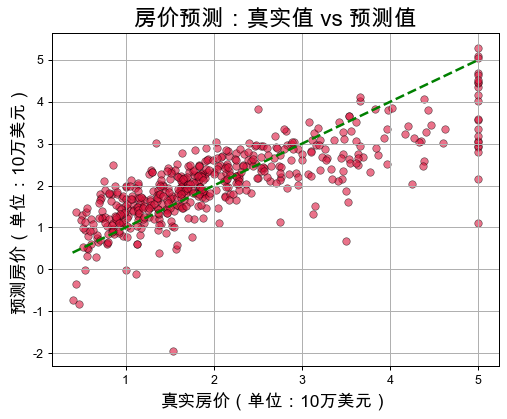

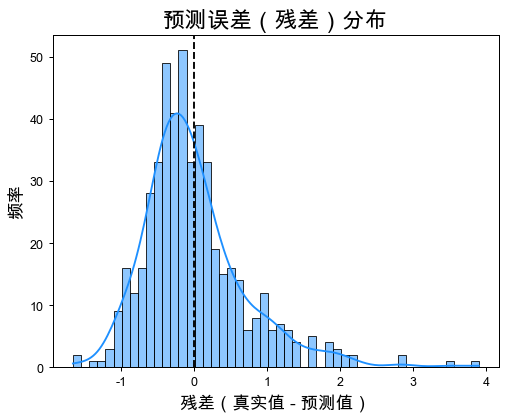

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from notebook_support import load_local_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. 加载数据
data = load_local_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedianHouseValue")

# 2. 数据展示（探索性分析）
print(X.head())

# 3. 训练测试集划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 模型构建与训练
model = LinearRegression()
model.fit(X_train, y_train)

# 5. 模型预测
y_pred = model.predict(X_test)

# 6. 计算均方误差
mse = mean_squared_error(y_test, y_pred)
print(f"\n均方误差 MSE：{mse:.4f}")

# 7. 可视化真实值 vs 预测值
plt.figure()
sns.scatterplot(x=y_test, y=y_pred, color="crimson", alpha=0.6, edgecolor="black")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', linewidth=2)
plt.title("房价预测：真实值 vs 预测值", fontsize=18)
plt.xlabel("真实房价（单位：10万美元）", fontsize=14)
plt.ylabel("预测房价（单位：10万美元）", fontsize=14)
plt.grid(True)
plt.show()

# 8. 残差分析图（误差分布）
residuals = y_test - y_pred
plt.figure()
sns.histplot(residuals, kde=True, color="dodgerblue", bins=50)
plt.axvline(x=0, color='black', linestyle='--')
plt.title("预测误差（残差）分布", fontsize=18)
plt.xlabel("残差（真实值 - 预测值）", fontsize=14)
plt.ylabel("频率", fontsize=14)
plt.show()

#### 1. 数据加载与预处理

我们用的是 `sklearn` 内置的加州房价数据集，包含人口、收入、房屋年龄等多个特征。

In [3]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedianHouseValue")

- `X` 是特征变量，如 `MedInc`（收入中位数）、`HouseAge`（房龄）。
- `y` 是目标变量，表示区域房价的中位数（单位是 10 万美元）。

#### 2. 数据划分

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

将数据集划分为：

- 80% 训练集用于训练模型
- 20% 测试集用于验证模型的泛化能力

随机种子（`random_state=42`）是为了确保结果可复现。

#### 3. 模型训练

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


我们使用线性回归模型来预测房价。这是一个简单的回归算法，易于解释和部署。

#### 4. 预测与评估

In [6]:
y_pred = model.predict(X_test) 
mse = mean_squared_error(y_test, y_pred)

- `y_pred` 是模型对测试集的预测结果。
- `mean_squared_error()` 函数计算预测值与真实值之间的 MSE。

#### 5. 可视化结果（真实值 vs 预测值）

<Axes: xlabel='MedianHouseValue'>

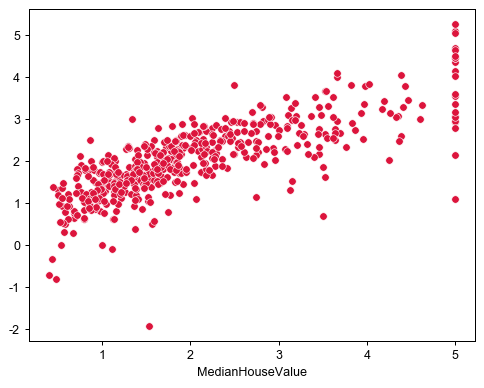

In [7]:
sns.scatterplot(x=y_test, y=y_pred, color="crimson")

我们将真实房价和预测房价，对应画在图中，理想情况是所有点都落在绿色虚线（`y = x`）上。

![原文参考图，当前结果见代码输出](attachments/img_005.png)

#### 6. 残差分析图

<Axes: xlabel='MedianHouseValue', ylabel='Count'>

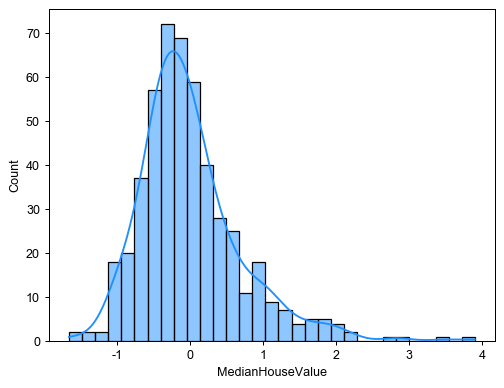

In [8]:
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color="dodgerblue")

残差是指：


$$
\text{残差} = y_{\text{真实}} - y_{\text{预测}}
$$


我们使用直方图观察残差分布。如果模型表现良好，残差应接近于0并且近似正态分布。

![原文参考图，当前结果见代码输出](attachments/img_006.png)

## 模型分析

### 均方误差的优缺点

**优点**：

1. **数学性质好**：MSE 是可导函数，利于梯度下降算法优化，广泛用于训练过程中的损失函数。
2. **强调大误差**：由于平方操作，模型对“大偏差”非常敏感，适合对误差容忍度低的场景。
3. **应用广泛**：在回归任务中，MSE 是最常用、最经典的评价指标之一。

**缺点**：

1. **单位问题**：MSE 的单位是原始单位的平方，不直观（如房价预测中单位是 $\text{美元}^2$）。
2. **对异常值敏感**：大误差被平方后会极度放大，导致一个极端值就可能拉高整个 MSE。
3. **不可解释性较差**：与 MAE 相比，MSE 难以直接解释为“平均错了多少钱”。

### 适用场景讨论：MSE 何时是“优选”？

MSE 非常适合以下几类问题：

1. **大多数预测接近真实值，偶尔有大误差时**：MSE 会对这些大误差惩罚很重，有助于模型更精准地对所有数据进行拟合，尤其适合科学计算类问题（如金融风险预测、天气模拟等）。
2. **模型训练中作为损失函数**：由于 MSE 可导，梯度下降可以轻松找到损失最小的方向。神经网络和线性回归模型都普遍使用 MSE 作为训练损失函数。
3. **样本集较大，异常值不多**：在大样本集下，极端值的影响可以被稀释，MSE 能比较全面反映整体误差结构。
4. **你更关心“大错误”的影响**：如果你在某些场景中希望模型特别警惕“错误很离谱的情况”，MSE 是理想选择。比如自动驾驶系统中的障碍物距离预测，错误太大可能带来严重后果。

## 总结

均方误差（MSE）作为机器学习中最基本的模型评估方法之一，具有以下核心价值：

- **数学原理简单，使用方便**
- **适合训练过程中的优化目标**
- **适用于大多数标准回归任务**

在上面的例子中，我们用 MSE 对房价回归模型进行有效评估，通过可视化手段揭示模型性能表现，验证其残差分布特性，为后续模型调优提供基础。

当然，MSE 也有它的缺点，它对异常值太敏感、单位难以解释。因此，在实际工作中，我们往往会配合使用其他指标（如 MAE、R²、RMSE 等）共同评估模型，形成更完整的判断。